# YOLOv8 확인하기

## 프로젝트 목표

사전학습된 YOLOv8을 제조 현장 데이터로 학습시켜 보고, 결과 숫자가 실제로 무엇을 뜻하는지 이해한다.

In [ ]:
!pip install ultralytics

### Yolo 이해

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Admin\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO('yolov8n.pt')

100%|█████████████████████████████████████████████████████████████████████████████| 6.25M/6.25M [00:00<00:00, 12.2MB/s]


In [ ]:
example_imgs = ['https://ultralytics.com/images/bus.jpg']

In [ ]:
from PIL import Image
import requests
from io import BytesIO

In [ ]:
response = requests.get(example_imgs[0])
img = Image.open(BytesIO(response.content))

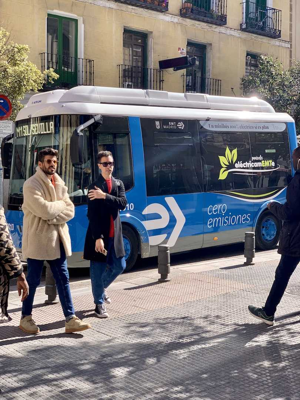

In [ ]:
img.thumbnail((400,400))
img

In [ ]:
results = model.predict(example_imgs[0], save=True, conf=0.25)


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 C:\Users\Admin\Downloads\drive-download-20250715T031121Z-1-001\\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 143.6ms
Speed: 3.7ms preprocess, 143.6ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to runs\detect\predict


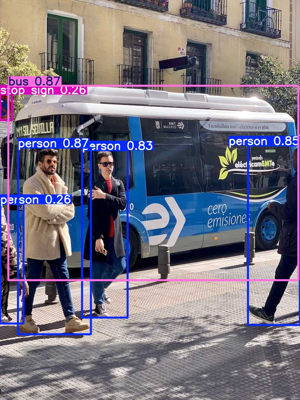

In [ ]:
output_img = Image.open('./runs/detect/predict/bus.jpg')
output_img.thumbnail((400,400))
output_img

이미지에서 가려진 stop sign(cls 11)의 conf 값이 0.26으로 꽤 낮다. 제일 왼쪽에 팔만 얼핏 보이는 사람도 0.26으로 잡는 것을 보면, 사전학습 모델이 가려진 물체도 일단 잡아내긴 한다. 그러나 0.26은 "잡았지만 확신은 없다"는 뜻이라, 시나리오에 따라 이게 좋은 것인지 위험한 것인지 가려야 한다.

검사 라인이라면 이런 낮은 신뢰도 결과는 자동 판정에 쓰지 않고 재검 대상으로 넘기는 편이 안전하겠다.

In [ ]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

[102, 92, 98]은 픽셀 한 개의 색 값 세 개(파랑, 초록, 빨강 순서)다. shape=(1080, 810, 3)은 세로 1080칸, 가로 810칸이고 칸마다 색 숫자가 3개씩 있다는 뜻이다.

결국 orig_img는 원본 사진을 숫자로 통째로 들고 있는 것이고, 나중에 박스를 그릴 때 쓴다.

In [ ]:
type(results)

list

In [ ]:
type(results[0])

ultralytics.engine.results.Results

In [ ]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 5.,  0.,  0.,  0.,  0., 11.])
conf: tensor([0.8734, 0.8657, 0.8528, 0.8252, 0.2611, 0.2551])
data: tensor([[2.2871e+01, 2.3128e+02, 8.0500e+02, 7.5684e+02, 8.7345e-01, 5.0000e+00],
        [4.8550e+01, 3.9855e+02, 2.4535e+02, 9.0270e+02, 8.6569e-01, 0.0000e+00],
        [6.6947e+02, 3.9219e+02, 8.0972e+02, 8.7704e+02, 8.5284e-01, 0.0000e+00],
        [2.2152e+02, 4.0580e+02, 3.4497e+02, 8.5754e+02, 8.2522e-01, 0.0000e+00],
        [0.0000e+00, 5.5053e+02, 6.3007e+01, 8.7344e+02, 2.6111e-01, 0.0000e+00],
        [5.8167e-02, 2.5446e+02, 3.2557e+01, 3.2487e+02, 2.5507e-01, 1.1000e+01]])
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([6, 6])
xywh: tensor([[413.9370, 494.0589, 782.1314, 525.5631],
        [146.9480, 650.6275, 196.7952, 504.1504],
        [739.5964, 634.6107, 140.2471, 484.8495],
        [283.2440, 631.6676, 123.4533, 451.7380],
        [ 31.5035, 711.9840,  63.0069, 322.9179],
     

탐지해낸 boxes의 cls가 각각 5, 0, 0, 0, 0, 11이다. 위의 클래스 목록과 매칭하면 5=bus, 0=person, 11=stop sign이다. conf 값은 우리가 설정한 threshold 0.25 이상인 것만 남아 있다. data tensor의 열 순서는 [x1, y1, x2, y2, conf, cls]로, 5번째 칸이 conf이고 마지막 칸이 class다.

In [ ]:
url = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/coco.yaml"

In [ ]:
import yaml
import requests=

url = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/coco.yaml"

response = requests.get(url)
data = yaml.safe_load(response.text)

print(data)

{'path': 'coco', 'train': 'train2017.txt', 'val': 'val2017.txt', 'test': 'test-dev2017.txt', 'names': {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toi

In [ ]:
results[0].boxes.conf

tensor([0.8734, 0.8657, 0.8528, 0.8252, 0.2611, 0.2551])

In [ ]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 5.,  0.,  0.,  0.,  0., 11.])
conf: tensor([0.8734, 0.8657, 0.8528, 0.8252, 0.2611, 0.2551])
data: tensor([[2.2871e+01, 2.3128e+02, 8.0500e+02, 7.5684e+02, 8.7345e-01, 5.0000e+00],
        [4.8550e+01, 3.9855e+02, 2.4535e+02, 9.0270e+02, 8.6569e-01, 0.0000e+00],
        [6.6947e+02, 3.9219e+02, 8.0972e+02, 8.7704e+02, 8.5284e-01, 0.0000e+00],
        [2.2152e+02, 4.0580e+02, 3.4497e+02, 8.5754e+02, 8.2522e-01, 0.0000e+00],
        [0.0000e+00, 5.5053e+02, 6.3007e+01, 8.7344e+02, 2.6111e-01, 0.0000e+00],
        [5.8167e-02, 2.5446e+02, 3.2557e+01, 3.2487e+02, 2.5507e-01, 1.1000e+01]])
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([6, 6])
xywh: tensor([[413.9370, 494.0589, 782.1314, 525.5631],
        [146.9480, 650.6275, 196.7952, 504.1504],
        [739.5964, 634.6107, 140.2471, 484.8495],
        [283.2440, 631.6676, 123.4533, 451.7380],
        [ 31.5035, 711.9840,  63.0069, 322.9179],
     

In [ ]:
img.size

(300, 400)

In [ ]:
results[0].boxes.xywh

tensor([[413.9370, 494.0589, 782.1314, 525.5631],
        [146.9480, 650.6275, 196.7952, 504.1504],
        [739.5964, 634.6107, 140.2471, 484.8495],
        [283.2440, 631.6676, 123.4533, 451.7380],
        [ 31.5035, 711.9840,  63.0069, 322.9179],
        [ 16.3078, 289.6668,  32.4992,  70.4148]])

In [ ]:
results[0].boxes.xywhn

tensor([[0.5110, 0.4575, 0.9656, 0.4866],
        [0.1814, 0.6024, 0.2430, 0.4668],
        [0.9131, 0.5876, 0.1731, 0.4489],
        [0.3497, 0.5849, 0.1524, 0.4183],
        [0.0389, 0.6592, 0.0778, 0.2990],
        [0.0201, 0.2682, 0.0401, 0.0652]])

In [ ]:
import cv2
import requests
import numpy as np
from PIL import Image
from io import BytesIO

img_url = "https://ultralytics.com/images/bus.jpg"
response = requests.get(img_url)
img = Image.open(BytesIO(response.content)).convert("RGB")
img_np = np.array(img)
height, width = img_np.shape[:2]

In [ ]:
height, width

(1080, 810)

In [ ]:
bbox1 = results[0].boxes.xywh[0]
bbox1

tensor([413.9370, 494.0589, 782.1314, 525.5631])

In [ ]:
bbox1[0]/width, bbox1[1]/height, bbox1[2]/width, bbox1[3]/height

(tensor(0.5110), tensor(0.4575), tensor(0.9656), tensor(0.4866))

In [ ]:
results[0].boxes.xywhn

tensor([[0.5110, 0.4575, 0.9656, 0.4866],
        [0.1814, 0.6024, 0.2430, 0.4668],
        [0.9131, 0.5876, 0.1731, 0.4489],
        [0.3497, 0.5849, 0.1524, 0.4183],
        [0.0389, 0.6592, 0.0778, 0.2990],
        [0.0201, 0.2682, 0.0401, 0.0652]])

In [ ]:
bbox2 = results[0].boxes.xyxy[0]
bbox2

tensor([ 22.8713, 231.2773, 805.0027, 756.8405])

In [ ]:
bbox2[0]/width, bbox2[1]/height, bbox2[2]/width, bbox2[3]/height

(tensor(0.0282), tensor(0.2141), tensor(0.9938), tensor(0.7008))

In [ ]:
results[0].boxes.xyxyn[0]

tensor([0.0282, 0.2141, 0.9938, 0.7008])

| 이름 | 뜻 | 값의 범위 |
| --- | --- | --- |
| xyxy | 왼쪽위, 오른쪽아래 | 픽셀 |
| xywh | 중심, 폭, 높이 | 픽셀 |
| xyxyn | 위와 같음 | 0 ~ 1 |
| xywhn | 위와 같음 | 0 ~ 1 |

박스 형식은 이렇게 정리할 수 있다.

이 중 YOLO 라벨 파일(.txt)이 쓰는 형식은 xywhn이다. 정규화해 두면 이미지 크기가 바뀌어도 라벨을 고칠 필요가 없기 때문이다. stamp 데이터의 라벨을 열어보면 `1 0.645 0.269 0.048 0.084`처럼 되어 있는데, 이게 [class, x, y, w, h]의 xywhn이다.

### 시각화

In [ ]:
url = "https://ultralytics.com/images/bus.jpg"
response = requests.get(url)
img = np.array(Image.open(BytesIO(response.content)).convert("RGB"))
h, w = img.shape[:2]
img_copy = img.copy()

In [ ]:
xyxy_coordinate = results[0].boxes.xyxy.cpu().numpy()

In [ ]:
xyxy_coordinate

array([[     22.871,      231.28,         805,      756.84],
       [      48.55,      398.55,      245.35,       902.7],
       [     669.47,      392.19,      809.72,      877.04],
       [     221.52,       405.8,      344.97,      857.54],
       [          0,      550.53,      63.007,      873.44],
       [   0.058167,      254.46,      32.557,      324.87]], dtype=float32)

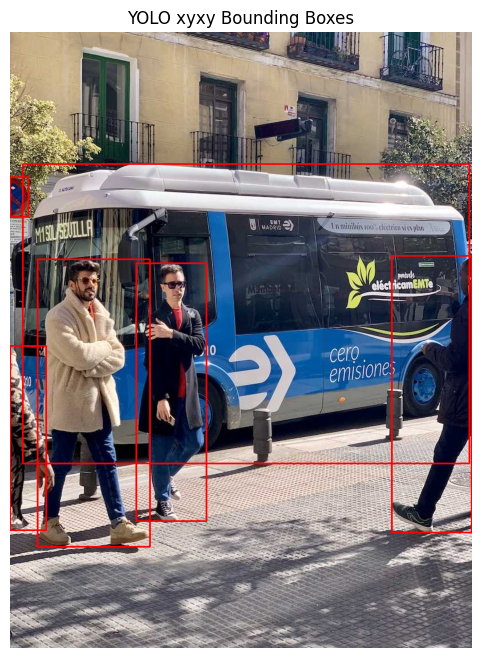

In [ ]:
import matplotlib.pyplot as plt

for box in xyxy_coordinate:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img_copy, (x1, y1), (x2, y2), color=(255, 0, 0), thickness=2)

# 시각화
plt.figure(figsize=(10, 8))
plt.imshow(img_copy)
plt.title("YOLO xyxy Bounding Boxes")
plt.axis("off")
plt.show()

뒤의 창문은 탐지하지 못한다. 학습이 안 된 건가? names에 '창문'을 넣기만 하면 되나? 아니다. 이 모델이 처음부터 배운 80개 목록에 창문이 없으니 못 잡는 것이 당연하고, 이름만 추가한다고 생김새를 아는 것은 아니다. 창문 사진에 박스 라벨을 단 데이터를 만들어 학습시켜야 한다.


In [ ]:
results[0].boxes.data

tensor([[2.2871e+01, 2.3128e+02, 8.0500e+02, 7.5684e+02, 8.7345e-01, 5.0000e+00],
        [4.8550e+01, 3.9855e+02, 2.4535e+02, 9.0270e+02, 8.6569e-01, 0.0000e+00],
        [6.6947e+02, 3.9219e+02, 8.0972e+02, 8.7704e+02, 8.5284e-01, 0.0000e+00],
        [2.2152e+02, 4.0580e+02, 3.4497e+02, 8.5754e+02, 8.2522e-01, 0.0000e+00],
        [0.0000e+00, 5.5053e+02, 6.3007e+01, 8.7344e+02, 2.6111e-01, 0.0000e+00],
        [5.8167e-02, 2.5446e+02, 3.2557e+01, 3.2487e+02, 2.5507e-01, 1.1000e+01]])

In [ ]:
det = results[0].boxes.data.cpu().numpy()

In [ ]:
type(det)

numpy.ndarray

In [ ]:
type(det)

numpy.ndarray

In [ ]:
url = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/coco.yaml"

# URL에서 YAML 텍스트 불러오기
response = requests.get(url)
yaml_content = response.text

# YAML 파싱
parsed = yaml.safe_load(yaml_content)

# 클래스 이름 추출
class_names = parsed['names']


In [ ]:
class_names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

데이터 클래스를 확인하였다
-> 시나리오 기반으로 생각할때는 필요없는 클래스들이 많아보인다
=> 액션

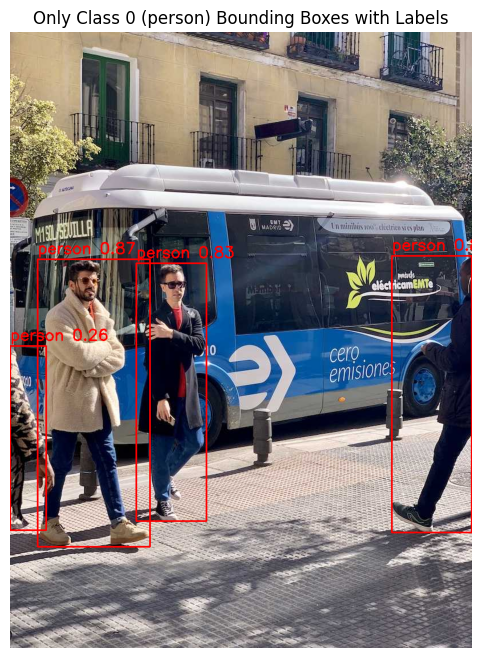

In [ ]:
img_copy = img_np.copy()


for det in results[0].boxes.data:
    x1, y1, x2, y2, conf, cls = det.tolist()
    if int(cls) == 0:
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        label = f"{class_names[int(cls)]} {conf:.2f}"
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img_copy, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.9, (255, 0, 0), 2)


plt.figure(figsize=(10, 8))
plt.imshow(img_copy)
plt.title("Only Class 0 (person) Bounding Boxes with Labels")
plt.axis("off")
plt.show()

반쯤 가려진 사람도 잘 찾았다.
버스는 찾지않아도 되니까 결과 시각화에서 제외한다.
목표(시나리오)에 따르면 표지판에 대해서 찾을 수 있어야한다. -> 어떤 작업이 필요한ㄷ가?

In [ ]:
import os
bus_class_id = [k for k, v in class_names.items() if v == 'bus'][0]
os.makedirs("bus_crops", exist_ok=True)

count = 0
for det in results[0].boxes.data:
    x1, y1, x2, y2, conf, cls = det.tolist()
    if int(cls) == bus_class_id:
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        cropped = img_np[y1:y2, x1:x2]
        save_path = f"bus_crops/bus_crop_{count}.jpg"
        cv2.imwrite(save_path, cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR))
        print(f"버스 {count}번 잘라서 저장: {save_path}")
        count += 1

버스 0번 잘라서 저장: bus_crops/bus_crop_0.jpg


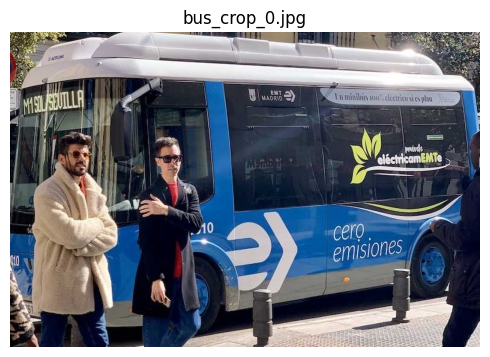

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

crop_folder = "bus_crops"

image_files = sorted([f for f in os.listdir(crop_folder) if f.endswith(".jpg")])

num_images = len(image_files)
plt.figure(figsize=(5 * num_images, 5))

for i, filename in enumerate(image_files):
    img_path = os.path.join(crop_folder, filename)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV는 BGR로 불러오기 때문에 RGB로 변환

    plt.subplot(1, num_images, i + 1)
    plt.imshow(img)
    plt.title(filename)
    plt.axis("off")

plt.tight_layout()
plt.show()


# YOLOv8 학습 실습

#### 데이터셋 다운로드
https://universe.roboflow.com/warisara-kaewsuwan-cf2hs/stamp-bcrhe

![image-3.png](attachment:image-3.png)

In [ ]:
from ultralytics import YOLO
import os

model = YOLO("yolov8n.pt")

* `datasets`
    * `stamp`
        * `test`
        * `train`
        * `valid`
        * `data.yaml`

> **아래 학습 셀은 실행하지 않는다.** 학습은 이미 끝났고 결과가 드라이브 `cv_projects/yolov8/runs/detect/stamp_detect-2/`에 있다. 20 epoch, imgsz 640, batch 16, T4 GPU로 돌렸고 best epoch는 17이었다. 아래 두 셀 뒤의 설정 셀에서 그 가중치를 불러와 평가부터 이어간다.

In [ ]:
model.train(
    data="../datasets/stamp/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    name="stamp_detect",
    device=0
)

New https://pypi.org/project/ultralytics/8.3.158 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.102 🚀 Python-3.10.16 torch-2.7.0+cu126 CUDA:0 (NVIDIA A100 80GB PCIe, 81093MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=../datasets/stamp/data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=stamp_detect2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, sho

train: Scanning /data/lecture/modu/hanwha/datasets/stamp/train/labels.cache... 1100 images, 0 backgrounds, 0 corrupt: 100%|██████
val: Scanning /data/lecture/modu/hanwha/datasets/stamp/valid/labels... 273 images, 0 backgrounds, 0 corrupt: 100%|██████████| 273

val: New cache created: /data/lecture/modu/hanwha/datasets/stamp/valid/labels.cache


Plotting labels to runs/detect/stamp_detect2/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs/detect/stamp_detect2
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/20      2.12G      1.034      1.674      1.029         86        640: 100%|██████████| 69/69 [00:07<00:00,  9.78it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:01<00:00,  7.4

...

                   all        273        952      0.954      0.971      0.984      0.642



20 epochs completed in 0.041 hours.
Optimizer stripped from runs/detect/stamp_detect2/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/stamp_detect2/weights/best.pt, 6.2MB

Validating runs/detect/stamp_detect2/weights/best.pt...
Ultralytics 8.3.102 🚀 Python-3.10.16 torch-2.7.0+cu126 CUDA:0 (NVIDIA A100 80GB PCIe, 81093MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:01<00:00,  5.1


                   all        273        952      0.979      0.903      0.982      0.656
                 shoes        204        408      0.962      0.815      0.968      0.719
                 stamp        273        544      0.996      0.991      0.995      0.592
Speed: 0.1ms preprocess, 0.4ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to runs/detect/stamp_detect2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f1a30d66110>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

dfl loss는 cls loss에 비해 크게 줄어들지 않는다. cls는 "이게 shoes냐 stamp냐"를 묻는데 두 클래스가 생김새부터 달라서 금방 배운다. dfl은 "박스 테두리가 정확히 몇 픽셀에 있냐"를 묻는데, stamp가 한 변 29px로 작아서 몇 픽셀만 어긋나도 크게 틀린 것이 되고, 라벨 박스 자체도 프레임마다 조금씩 다르게 그려져 있어서 정답이 흔들린다. 그래서 val에서 dfl이 평평하다. 분류는 됐는데 위치 정밀도가 병목이다.

In [ ]:
# 학습은 이미 끝났으므로, 드라이브에 저장된 best.pt를 불러와 평가와 예측만 다시 실행한다.
!pip -q install ultralytics
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE = '/content/drive/MyDrive/cv_projects'
os.makedirs('/content/datasets/stamp', exist_ok=True)
os.makedirs('/content/work', exist_ok=True)
if not os.path.exists('/content/datasets/stamp/data.yaml'):
    !unzip -q {DRIVE}/stamp.zip -d /content/datasets/stamp
os.chdir('/content/work')          # 아래 셀들의 ../datasets 경로가 맞도록 작업 위치를 잡는다

from ultralytics import YOLO
WEIGHTS = f'{DRIVE}/yolov8/runs/detect/stamp_detect-2/weights/best.pt'
model = YOLO(WEIGHTS)
print('작업 위치:', os.getcwd())
print('가중치   :', WEIGHTS)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.7/77.7 kB 2.7 MB/s eta 0:00:00
Mounted at /content/drive
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
작업 위치: /content/work
가중치   : /content/drive/MyDrive/cv_projects/yolov8/runs/detect/stamp_detect-2/weights/best.pt


In [ ]:
metrics = model.val(data='../datasets/stamp/data.yaml')
print("평가 결과:", metrics.box.map50, metrics.box.map)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 606.4±247.9 MB/s, size: 27.4 KB)
val: Scanning /content/datasets/stamp/valid/labels... 273 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 273/273 1.5Kit/s 0.2s
val: New cache created: /content/datasets/stamp/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 4.7s/it 1:24
                   all        273        952      0.943      0.938      0.984      0.627
                 shoes        204        408       0.92      0.877      0.973      0.707
                 stamp        273        544      0.966          1      0.995      0.547
Speed: 10.0ms preprocess, 284.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/work/runs/detect/val
평가 결과: 0.9841758958681828 0

In [ ]:
# 평가 결과를 표로 정리 (metrics 객체에서 직접 읽으므로 내 결과가 그대로 들어간다)
import pandas as pd

rows = [{
    "Class": "all",
    "Precision": round(float(metrics.box.mp), 3),
    "Recall": round(float(metrics.box.mr), 3),
    "mAP@.5": round(float(metrics.box.map50), 3),
    "mAP@.5:.95": round(float(metrics.box.map), 3),
}]
for i, name in metrics.names.items():
    prec, rec, ap50, ap = metrics.box.class_result(i)
    rows.append({"Class": name, "Precision": round(float(prec), 3), "Recall": round(float(rec), 3),
                 "mAP@.5": round(float(ap50), 3), "mAP@.5:.95": round(float(ap), 3)})

df = pd.DataFrame(rows)
print(df.to_markdown(index=False))

| Class   |   Precision |   Recall |   mAP@.5 |   mAP@.5:.95 |
|:--------|------------:|---------:|---------:|-------------:|
| all     |       0.943 |    0.938 |    0.984 |        0.627 |
| shoes   |       0.92  |    0.877 |    0.973 |        0.707 |
| stamp   |       0.966 |    1     |    0.995 |        0.547 |


stamp는 mAP50이 0.995인데 mAP50-95는 0.547이다. 절반만 겹치면 정답으로 쳐주는 기준에서는 거의 만점인데, 엄격하게 겹쳐야 하는 기준에서는 절반 정도다. 즉 대충 영역에 걸치기만 하는 수준으로 잡고 있다.

이유는 stamp가 작기 때문이다. 29px짜리 박스가 3px만 어긋나도 IoU가 0.65 정도로 떨어지지만, 76px인 shoes는 같은 3px 오차에도 0.85가 나온다. 작을수록 픽셀 오차가 치명적이다.

In [ ]:
metrics.box.map, metrics.box.map50, metrics.box.map75, metrics.box.maps

(np.float64(0.626861207798321),
 np.float64(0.9841758958681828),
 np.float64(0.7073600418689994),
 array([    0.70699,     0.54673]))

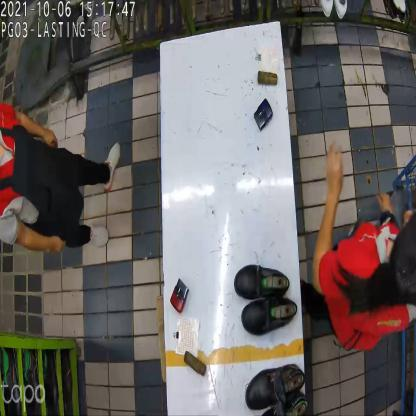

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open('../datasets/stamp/test/images/clip1_mp4-33_jpg.rf.95be2fb4fbae44fb12fd600d1d966f76.jpg')

image

In [ ]:
results = model.predict('../datasets/stamp/test/images/clip1_mp4-33_jpg.rf.95be2fb4fbae44fb12fd600d1d966f76.jpg')
results[0].save(filename='predicted1.jpg')


image 1/1 /content/work/../datasets/stamp/test/images/clip1_mp4-33_jpg.rf.95be2fb4fbae44fb12fd600d1d966f76.jpg: 640x640 1 shoes, 2 stamps, 322.9ms
Speed: 9.7ms preprocess, 322.9ms inference, 7.3ms postprocess per image at shape (1, 3, 640, 640)


'predicted1.jpg'

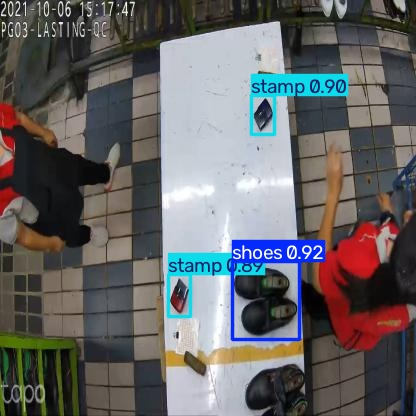

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("predicted1.jpg")

image

최하단 신발은 탐지하지 않았네.

정답 라벨을 확인하면 이 사진에는 shoes 2개, stamp 2개가 있는데 모델은 shoes 1개, stamp 2개만 잡았다. 놓친 shoes의 라벨은 `0 0.662 0.938 0.156 0.123`으로, 박스 아래쪽 끝이 0.999다. 즉 화면 맨 아래에 닿아 잘린 신발이다.

검증 세트에서 shoes 재현율이 0.877로 stamp(1.0)보다 낮았는데, 놓친 것들을 눈으로 확인하면 이렇게 프레임 가장자리에 잘린 경우가 반복된다. 1부에서 버스 사진의 왼쪽 가장자리 사람이 conf 0.26으로 낮게 나왔던 것과 같은 현상이다.

=> 카메라 화각을 작업대 전체가 들어오도록 잡거나, 가장자리에 걸친 물체는 다음 프레임에서 다시 판정하도록 하는 것이 액션이 되겠다.

In [ ]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 1., 1.])
conf: tensor([0.9206, 0.8974, 0.8858])
data: tensor([[232.2744, 261.1083, 299.2316, 339.0576,   0.9206,   0.0000],
        [251.9472,  95.6138, 274.3788, 134.2766,   0.8974,   1.0000],
        [168.6953, 274.5876, 190.4470, 316.5714,   0.8858,   1.0000]])
id: None
is_track: False
orig_shape: (416, 416)
shape: torch.Size([3, 6])
xywh: tensor([[265.7530, 300.0829,  66.9572,  77.9492],
        [263.1630, 114.9452,  22.4316,  38.6628],
        [179.5711, 295.5795,  21.7518,  41.9839]])
xywhn: tensor([[0.6388, 0.7214, 0.1610, 0.1874],
        [0.6326, 0.2763, 0.0539, 0.0929],
        [0.4317, 0.7105, 0.0523, 0.1009]])
xyxy: tensor([[232.2744, 261.1083, 299.2316, 339.0576],
        [251.9472,  95.6138, 274.3788, 134.2766],
        [168.6953, 274.5876, 190.4470, 316.5714]])
xyxyn: tensor([[0.5584, 0.6277, 0.7193, 0.8150],
        [0.6056, 0.2298, 0.6596, 0.3228],
        [0.4055, 0.6601, 0.4578, 0.7610]])

## 테스트 2: 테스트 세트 평가

검증 세트(valid)는 학습 중 매 epoch 성능을 재는 데 쓰였다. 한 번도 안 본 테스트 세트(test, 193장)로 다시 평가해서 결과가 유지되는지 확인한다.

In [9]:
metrics_test = model.val(data='../datasets/stamp/data.yaml', split='test', name='test_eval')

rows = [{"Class": "all", "Precision": round(float(metrics_test.box.mp), 3), "Recall": round(float(metrics_test.box.mr), 3),
         "mAP@.5": round(float(metrics_test.box.map50), 3), "mAP@.5:.95": round(float(metrics_test.box.map), 3)}]
for i, name in metrics_test.names.items():
    prec, rec, ap50, ap = metrics_test.box.class_result(i)
    rows.append({"Class": name, "Precision": round(float(prec), 3), "Recall": round(float(rec), 3),
                 "mAP@.5": round(float(ap50), 3), "mAP@.5:.95": round(float(ap), 3)})
print(pd.DataFrame(rows).to_markdown(index=False))

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 187.1±97.8 MB/s, size: 27.1 KB)
val: Scanning /content/datasets/stamp/test/labels... 193 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 193/193 1.2Kit/s 0.2s
val: New cache created: /content/datasets/stamp/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.9s/it 50.7s
                   all        193        633      0.981      0.931      0.987      0.628
                 shoes        141        250      0.973      0.867      0.979      0.707
                 stamp        193        383      0.988      0.995      0.995       0.55
Speed: 8.8ms preprocess, 239.7ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/work/runs/detect/test_eval
| Class   |   Precision 

검증과 테스트 결과에 크게 유의미한 차이는 없다. 전체 mAP50-95가 0.627과 0.628로 사실상 같고, 클래스별 패턴도 그대로다.

| Class | 검증 R | 테스트 R | 검증 mAP50-95 | 테스트 mAP50-95 |
| --- | --- | --- | --- | --- |
| shoes | 0.877 | 0.867 | 0.707 | 0.707 |
| stamp | 1.000 | 0.995 | 0.547 | 0.550 |

stamp는 재현율이 1.0에 가까운데 mAP50-95는 0.55에 머물고, shoes는 반대로 재현율이 0.87로 낮지만 mAP50-95는 0.71로 더 높다. 검증에서 본 "찾는 것과 정확히 그리는 것이 클래스별로 반대"라는 현상이 테스트에서도 그대로 재현된다.

## 데이터 분할에 대해 확인한 것

파일명이 `clip1_mp4-33`처럼 영상 프레임 번호라서, train/valid/test가 같은 영상의 프레임을 무작위로 나눈 것인지 확인했다.

In [10]:
import re, bisect
from collections import Counter

def frame_numbers(split):
    nums = []
    for f in os.listdir(f'../datasets/stamp/{split}/images'):
        m = re.match(r'clip\d+_mp4-(\d+)_', f)
        if m: nums.append(int(m.group(1)))
    return sorted(nums)

train, valid = frame_numbers('train'), frame_numbers('valid')
dists = []
for n in valid:
    i = bisect.bisect_left(train, n)
    dists.append(min(abs(train[j] - n) for j in (i - 1, i) if 0 <= j < len(train)))
c = Counter(dists)
print(f'valid {len(dists)}장 중 train 프레임과 거리 1: {c[1]}장, 거리 2 이내: {sum(v for k, v in c.items() if k <= 2)}장')

valid 210장 중 train 프레임과 거리 1: 137장, 거리 2 이내: 159장


valid 210장 중 159장(76%)이 train 프레임과 2프레임 이내에 있다. 30fps 영상에서 2프레임은 0.07초 차이라서 사실상 같은 장면이다. 즉 학습에 쓴 사진과 거의 같은 장면을 보고 검증이 진행된 것이다.

그러면 mAP50 0.98은 "본 것과 같은 장면에서" 나온 숫자다. 실제 공장에서 내일 찍힌 영상은 이런 이웃 프레임이 아니므로, 성능은 이보다 낮게 나올 가능성이 높다. 검증 점수를 그대로 믿기 전에 데이터가 어떻게 나뉘었는지부터 확인해야 한다는 것을 배웠다.

## 목표 기준 평가

달성했다. YOLO 모델의 입출력이 어떻게 이루어지는지 정확히 이해했다. 입력은 이미지 한 장이고, 출력은 객체의 이미지 속 위치(박스 좌표)와 class, 그리고 신뢰도다. 결과 숫자에서는 mAP50과 mAP50-95의 차이가 "찾았는가"와 "정확히 그렸는가"의 차이라는 것을 stamp 결과로 확인했다.

다만 한 가지가 남았다. 제조 현장에서 손이나 다른 물체에 가려진 것도 현실에서는 분명히 존재하는 물체인데, 모델은 낮은 신뢰도로 답한다. 이것을 어떻게 극복할지는 이 실습에서 답을 내지 못했다.

## 개인 회고 (KPT)

**Keep**

사전학습 모델을 제조 데이터로 학습시켰을 때 객체를 잘 찾고 위치도 잘 낸다. 사전학습 가중치를 받아서 내 데이터로 학습하고 평가하는 이 흐름은 그대로 쓸 수 있다.

**Problem**

가려진 부분이나 잘린 부분을 탐지하지 못하는 경우가 있다. 테스트 이미지에서 화면 최하단에 위치한 신발을 탐지하지 못했고, 검증 이미지에서도 같은 위치의 신발을 반복해서 놓쳤다.

**Try**

탐지하고 싶은 클래스를 추가하고 그 데이터를 학습시켜 탐지해 보고 싶다. 1부에서 창문을 못 잡았던 것처럼, 목록에 없는 물체를 직접 라벨링해서 넣어보는 것이다.